<a href="https://colab.research.google.com/github/NABI-SNU/book/blob/main/tutorials/Session_2_BayesianInference/student/Tutorial2.ipynb" target="_blank"><img alt="Open In Colab" src="https://colab.research.google.com/assets/colab-badge.svg"/></a>   <a href="https://kaggle.com/kernels/welcome?src=https://raw.githubusercontent.com/NABI-SNU/book/main/tutorials/Session_2_BayesianInference/student/Tutorial2.ipynb" target="_blank"><img alt="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"/></a>


# Tutorial 2: OLS likelihood, Gaussian prior (Ridge), Laplace prior (Lasso)

**Session 2: Bayesian Inference** · **NABI-SNU**


## Learning goals

1. Write the **Gaussian linear regression likelihood** (OLS setting) and its log form.
2. See **Ridge regression** as MAP under a **Gaussian prior** on coefficients.
3. Connect the **Laplace prior** to **Lasso** ($\ell_1$ penalty) at the MAP.
4. Visualize OLS, Ridge, and Lasso on a concrete polynomial-fit example.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sympy import symbols, log, simplify, sqrt, pi
from sympy import Rational

# scikit-learn for Exercise 4
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline

plt.rcParams.update({"figure.figsize": (6, 4), "axes.grid": True})


---

## Exercise 1 — Gaussian likelihood (scalar toy model)

Assume $y_i = \beta x_i + \varepsilon_i$ with $\varepsilon_i \stackrel{\text{iid}}{\sim}\mathcal{N}(0,\sigma^2)$, $i=1,\dots,n$.

1. Write the likelihood $p(\mathbf{y}\mid \beta, \sigma)$ (ignore constants w.r.t. $\beta$).
2. Show the **negative log-likelihood** is proportional to $\sum_i (y_i - \beta x_i)^2$ (up to $\sigma$).
3. In SymPy, define symbols for $\beta, \sigma$ and $(x_i, y_i)_{i=1}^3$ and form $\log p(\mathbf{y}\mid \beta, \sigma^2)$. Expand it and identify the quadratic in $\beta$. 

In [ ]:
# 1. Define symbolic variables:
beta, sig = symbols("beta sigma", positive=True)
x1, x2, x3 = symbols("x1 x2 x3", real=True)
y1, y2, y3 = symbols("y1 y2 y3", real=True)

# 2. Form the residual sum of squares:
r1, r2, r3 = y1 - beta * x1, y2 - beta * x2, y3 - beta * x3
rss = r1**2 + r2**2 + r3**2

# 3. The log-likelihood for n Gaussian residuals is
#    log p(y | beta, sigma) = -n * log(sigma * sqrt(2 pi)) - rss / (2 sigma^2)
raise NotImplementedError("Build log_like and inspect the quadratic in beta.")
log_like = ...

# 4. Expand and simplify:
expanded = simplify(log_like.expand())
expanded

---

## Exercise 2 — Gaussian prior → Ridge (MAP)

Place a prior $\beta \sim \mathcal{N}(0, \tau^2)$ (independent of the data model).

1. Write $\log p(\beta)$ up to constants.
2. Form $\log p(\beta) + \log p(\mathbf{y}\mid \beta)$ and identify the **MAP** as minimizing
   $$\|\mathbf{y}-\mathbf{X}\beta\|_2^2 + \lambda \|\beta\|_2^2$$
   with $\lambda = \sigma^2 / \tau^2$.
3. *(NumPy)* For a small design matrix $\mathbf{X}$ and vector $\mathbf{y}$, compute the **Ridge** closed form and compare to plain OLS when $\lambda \to 0$.

**Hint:** Ridge minimizes $Q(\beta) = \|\mathbf{y}-\mathbf{X}\beta\|_2^2 + \lambda\|\beta\|_2^2$. Setting the gradient to zero,
$\nabla_\beta Q = -2\mathbf{X}^{\mathsf T}(\mathbf{y}-\mathbf{X}\beta) + 2\lambda\beta = \mathbf{0}$,


In [ ]:
rng = np.random.default_rng(1)
n, p = 50, 3
X = rng.normal(size=(n, p))
beta_true = np.array([1.5, -0.5, 0.0])
y = X @ beta_true + 0.3 * rng.normal(size=n)

lam = 0.5
I = np.eye(p)

# 1. Plain OLS via least-squares:
beta_ols = np.linalg.lstsq(X, y, rcond=None)[0]

# 2. Ridge closed form: (X^T X + lambda I)^{-1} X^T y
raise NotImplementedError("Implement the Ridge closed-form solution.")
beta_ridge = ...

print("OLS:  ", beta_ols)
print("Ridge:", beta_ridge)
print("(true)", beta_true)


---

## Exercise 3 — Laplace prior → Lasso (MAP)

Use prior $p(\beta) \propto \exp(-\alpha |\beta|)$ (Laplace with rate $\alpha$).

1. Write the MAP objective as minimizing **MSE + $\ell_1$ penalty**, $\|\mathbf{y}-\mathbf{X}\beta\|_2^2 + \lambda \|\beta\|_1$ with $\lambda = 2\sigma^2 \alpha$.
2. Explain in one sentence why the **non-differentiability** of $|\beta|$ at zero encourages **exact zeros** of coefficients.
3. *(Plot)* On a grid $(\beta_1, \beta_2)$, compare **contours** of $\beta_1^2 + \beta_2^2$ ($\ell_2^2$) vs $|\beta_1|+|\beta_2|$ ($\ell_1$) and notice the **diamond** corners of the $\ell_1$ contours.


In [ ]:
# --- Hints (Exercise 3) -------------------------------------------------
b1 = np.linspace(-2, 2, 200)
b2 = np.linspace(-2, 2, 200)
B1, B2 = np.meshgrid(b1, b2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: l2-squared penalty contours
raise NotImplementedError("Plot l2^2 contours on axes[0].")
penalty_l2 = ...
axes[0].contour(B1, B2, penalty_l2, levels=[0.25, 0.5, 1, 1.5])
axes[0].set_title(r"$\ell_2^2$ penalty (Gaussian / Ridge)")
axes[0].set_xlabel(r"$\beta_1$")
axes[0].set_ylabel(r"$\beta_2$")

# Right: l1 penalty contours
penalty_l1 = ...
axes[1].contour(B1, B2, penalty_l1, levels=[0.5, 1, 1.5, 2])
axes[1].set_title(r"$\ell_1$ penalty (Laplace / Lasso)")
axes[1].set_xlabel(r"$\beta_1$")
axes[1].set_ylabel(r"$\beta_2$")
plt.tight_layout()
plt.show()


---

## Exercise 4 — OLS vs Ridge vs Lasso on noisy polynomial data

We generate noisy samples of $f(x) = \sin(1.5\pi x)$ on $x\in[0,1]$ and fit a **degree-12 polynomial** with three estimators:

- **OLS** — no penalty (typically overfits in this setup).
- **Ridge** ($\ell_2^2$ penalty) — shrinks coefficients smoothly.
- **Lasso** ($\ell_1$ penalty) — sets several coefficients **exactly to zero**.

You will:

1. Build polynomial features and fit all three models.
2. Plot the fitted curves against the true function.
3. Compare the **coefficients** as a bar chart (note Lasso's zeros).
4. *(Optional)* Trace **regularization paths** for Ridge and Lasso as $\alpha$ varies.


/opt/homebrew/Caskroom/miniconda/base/envs/book-py39/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/Caskroom/miniconda/base/envs/book-py39/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/Caskroom/miniconda/base/envs/book-py39/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/Caskroom/miniconda/base/envs/book-py39/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/Caskroom/miniconda/base/envs/book-py39/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/Caskroom/miniconda/base/envs/book-py39/lib/python3.9/

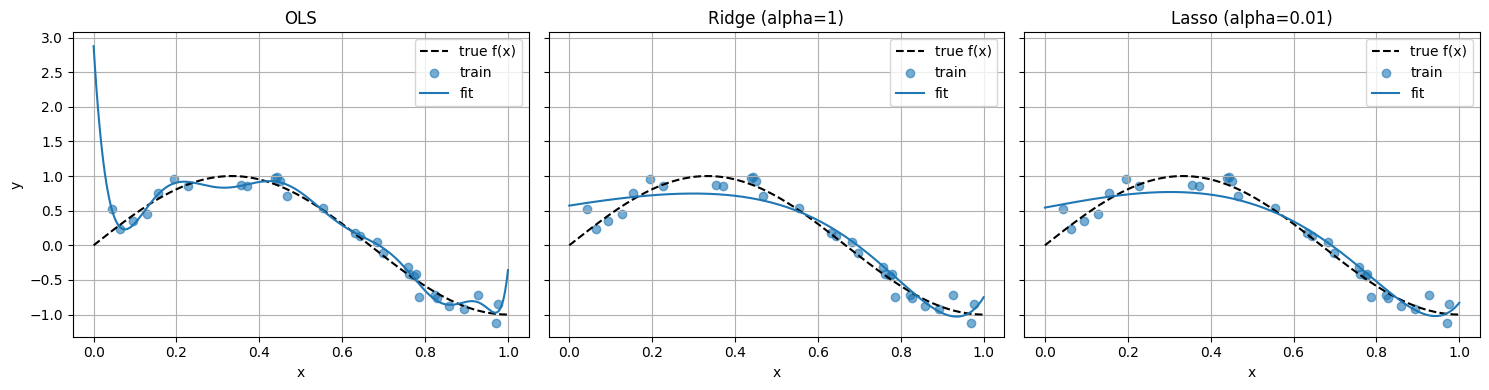

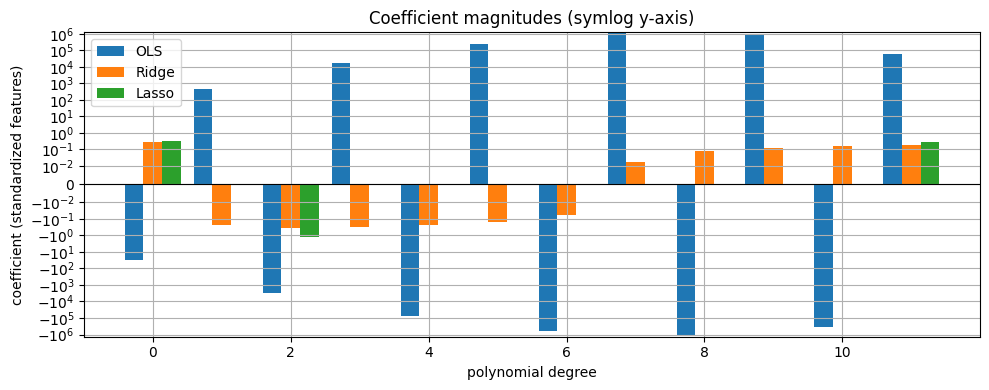

In [ ]:
# --- Hints (Exercise 4) -------------------------------------------------
# Step 1: synthetic data
rng = np.random.default_rng(42)
n_train = 30
x_train = np.sort(rng.uniform(0.0, 1.0, n_train))
y_train = np.sin(1.5 * np.pi * x_train) + 0.15 * rng.normal(size=n_train)

x_plot = np.linspace(0.0, 1.0, 300)
y_true = np.sin(1.5 * np.pi * x_plot)

# Step 2: pipeline = polynomial features (degree 12) -> standardize -> linear model
degree = 12

def make_pipeline_for(model):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

# Fill in the three estimators. Suggested hyperparameters: alpha=1.0 for Ridge,
# alpha=0.01 for Lasso. Lasso may need max_iter raised.
raise NotImplementedError("Construct OLS, Ridge, and Lasso pipelines and fit them.")
ols   = make_pipeline_for(...).fit(x_train.reshape(-1, 1), y_train)
ridge = make_pipeline_for(...).fit(x_train.reshape(-1, 1), y_train)
lasso = make_pipeline_for(...).fit(x_train.reshape(-1, 1), y_train)

# Step 3: plot fits next to the true function
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, model, name in zip(
    axes,
    [ols, ridge, lasso],
    ["OLS", "Ridge (alpha=1)", "Lasso (alpha=0.01)"],
):
    ax.plot(x_plot, y_true, "k--", label="true f(x)")
    ax.scatter(x_train, y_train, alpha=0.6, label="train")
    ax.plot(x_plot, model.predict(x_plot.reshape(-1, 1)), label="fit")
    ax.set_title(name)
    ax.set_xlabel("x")
    ax.legend()
axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()

# Step 4: compare coefficients
fig, ax = plt.subplots(figsize=(10, 4))
idx = np.arange(degree)
width = 0.27
ax.bar(idx - width, ols.named_steps["model"].coef_,   width, label="OLS")
ax.bar(idx,         ridge.named_steps["model"].coef_, width, label="Ridge")
ax.bar(idx + width, lasso.named_steps["model"].coef_, width, label="Lasso")
ax.axhline(0.0, color="k", linewidth=0.8)
ax.set_yscale("symlog", linthresh=0.01)
ax.set_xlabel("polynomial degree")
ax.set_ylabel("coefficient (standardized features)")
ax.set_title("Coefficient magnitudes (symlog y-axis)")
ax.legend()
plt.tight_layout()
plt.show()
